In [20]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:


#pip install torch torchvision pillow ipywidgets matplotlib numpy ipython
#Version gpu: pip install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu117

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torch.optim as optim

from torchvision import transforms
import torch.optim as optim
import ipywidgets as widgets
import matplotlib.pyplot as plt
import time
import numpy as np


In [22]:

import src.prepareData as prepareData
from torch.utils.data import DataLoader

#Lectura, carga y preparacion del dataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset_root = "Flickr2K"

train_dataset = prepareData.PrepareDataSet(root_dir=dataset_root, split="train", scale_factor=4, patch_size=128)
val_dataset   = prepareData.PrepareDataSet(root_dir=dataset_root, split="val",   scale_factor=4, patch_size=128)

#Ajustar el batch_size dependiendo de la gpu, el mio con 10 ya ocupa toda la VRAM de la gpu
#El numero de workers afecta a la cpu, tengo 8 nuecleos, asi que pongo 4 workers
train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True,  num_workers=4, pin_memory=True) # en entrenamiento mezclar el orden de los parches cada epoca nueva
val_loader   = DataLoader(val_dataset,   batch_size=10, shuffle=False, num_workers=4, pin_memory=True) #pin memory true pues  hago uso de gpu, tenerlo en true usando cpu no tiene mucho sentido

batch = next(iter(train_loader)) #toma el siguiente mini batch del train loader
lr_batch = batch["lr"].to(device, non_blocking=True) #[10, 3, 32, 32]
hr_batch = batch["hr"].to(device, non_blocking=True) #[10, 3, 128, 128]

#print("LR tamaño de batch:", lr_batch.shape, "Device:")
#print("HR tamaño de batch:", hr_batch.shape, "Device:")
print("Device: ", device)


Device:  cpu


Estructura a modelar, cumplirá la funcion de Generador en el modelo.

![Estructura RRDB](./resources/RRDB.png)

Estructura del generador

![Estructura RRDB](./resources/Generator.png)

Consideracion: La imagen anterior es el generador de un modelo SRGAN, lo que estamos modelando es un ESRGAN
por lo que debemos quitar las apariciones de la funcion de activacion BatchNorm y reemplazar los bloques por los nuestros (RRDB).

Estructura del discriminador

![Estructura RRDB](./resources/Discriminador.png)

Se mantiene la misma arquitectura, pero en la evaluación se determina qué tan “relativista” es una imagen para decidir si es real o fake.
Se omite la sigmoide en la evaluacion final porque en SRGAN simplemente determina si es real (1) o fake(0).
En su lugar, la última capa es una convolución que devuelve un mapa 2D de logits.

In [23]:
#Se especifica "we propose animproved perceptual loss by using the VGG features before activation instead of after activation as in SRGAN."

In [24]:
#Podemos proceder a definir todas las cosas que vamos a ocupar para el entrenamiento
from src.generator import RRDBNet
from src.discriminator import Discriminator
from src.vgg_features import VGGFeatureExtractor

generator = RRDBNet(
    in_channels=3,
    out_channels=3,
    num_features=64,
    growth_channels=32,
    num_blocks=23,
    scale=4
).to(device)

discriminator = Discriminator(in_channels=3, base_channels=64).to(device)
lr_initial = 5e-5 # Me equivoque y estaba ocupando el valor actual, tenia que ser 1e-4, esto se especifica en el paper

#Optimizadores adam  con los siguientes parametros es lo usual en ESRGAN
optimizer_G = optim.Adam(generator.parameters(), lr=lr_initial, betas=(0.9, 0.999)) #Optimizador para el generador
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr_initial, betas=(0.9, 0.999)) #Optimizador para el Discrimiandor
pixel_loss = nn.L1Loss().to(device)

vgg_extractor = VGGFeatureExtractor(layer_ids=[35], use_input_norm=True, device=device).to(device)
perceptual_loss = nn.L1Loss().to(device) 
bce_loss = nn.BCEWithLogitsLoss().to(device) #Probabilidades de real y fake por parte del discriminador





<p >  
  Fórmula para calcular el error del Discriminador:
</p>
<img src="./resources/formulaLossDis.png" alt="Loss D" width="800"/>
<br>
<p>  
  Fórmula para calcular el error del Generador:
</p>
<img src="./resources/formulaLossGen.png" alt="Loss G" width="800"/>

<p>  
  Donde:
</p>
<img src="./resources/Subformulas.png" alt="Loss G" width="600"/>


In [25]:
import os

In [ ]:


from src.train import train_model

os.makedirs('./checkpoints', exist_ok=True)

CONTINUAR_ENTRENAMIENTO = False 
CHECKPOINT_PATH = "./checkpoints/checkpoint_epoch_5.pth"

if CONTINUAR_ENTRENAMIENTO:
    print(f"Reanudando entrenamiento desde: {CHECKPOINT_PATH}")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    generator.load_state_dict(checkpoint["G_state_dict"])
    discriminator.load_state_dict(checkpoint["D_state_dict"])
    optimizer_G.load_state_dict(checkpoint["optimizer_G"])
    optimizer_D.load_state_dict(checkpoint["optimizer_D"])
    
    epoca_inicial = checkpoint["epoch"]
else:
    print("Iniciando entrenamiento desde cero...")
    epoca_inicial = 0
    os.makedirs('./checkpoints', exist_ok=True)

historial_perdidas = train_model(
    generator=generator, 
    discriminator=discriminator, 
    vgg_extractor=vgg_extractor, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    optimizer_G=optimizer_G, 
    optimizer_D=optimizer_D, 
    bce_loss=bce_loss, 
    pixel_loss=pixel_loss, 
    perceptual_loss=perceptual_loss, 
    device=device, 
    num_epochs=10, #Originalmente 150, ajustar este numero como un parametro global despues
    start_epoch=epoca_inicial
)


#Con un I511400H 6 nucleos 12 hilos y una rtx 3050 vram (laptop)
#Tomo un total de 8 horas de entrenamiento


Reanudando entrenamiento desde: ./checkpoints/checkpoint_epoch_5.pth


/tmp/ipykernel_22986/965002183.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)


Epoch [6/10], Pixel: 0.1243, Percep: 0.0935, Color: 0.1123, Tiempo de época: 2.1s
Epoch [7/10], Pixel: 0.1544, Percep: 0.1252, Color: 0.1284, Tiempo de época: 2.0s
Epoch [8/10], Pixel: 0.1248, Percep: 0.1005, Color: 0.1075, Tiempo de época: 2.1s
Epoch [9/10], Pixel: 0.1638, Percep: 0.1258, Color: 0.1683, Tiempo de época: 2.0s
Epoch [10/10], Pixel: 0.1022, Percep: 0.1629, Color: 0.1035, Tiempo de época: 2.1s
Entrenamiento completado en 10.9s (0.2 minutos).


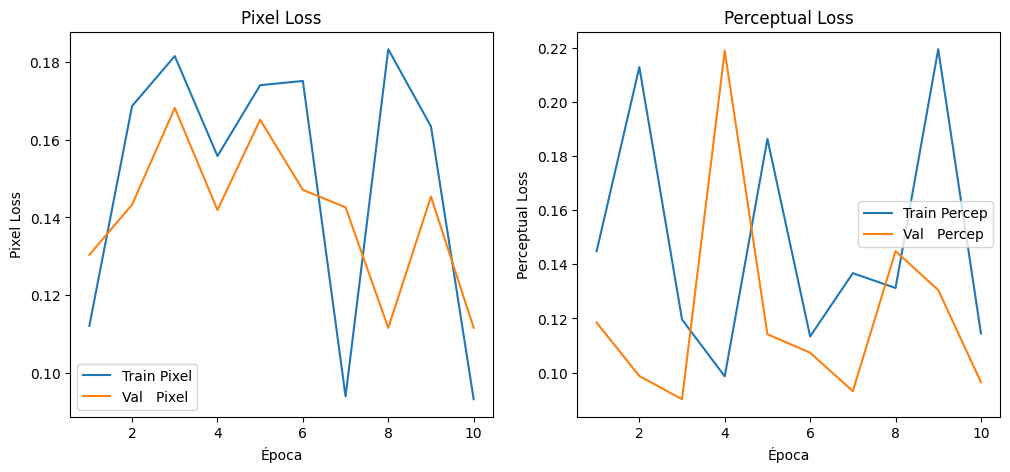

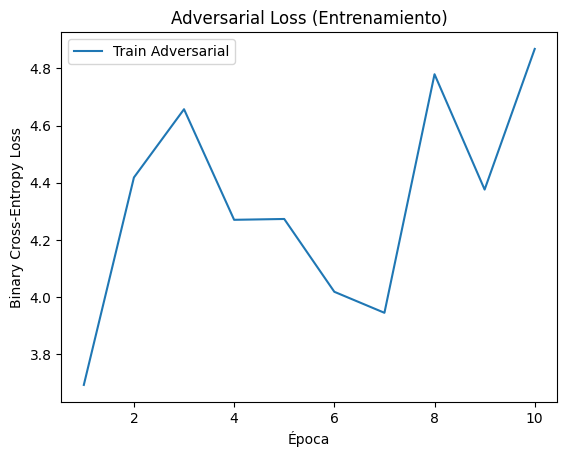

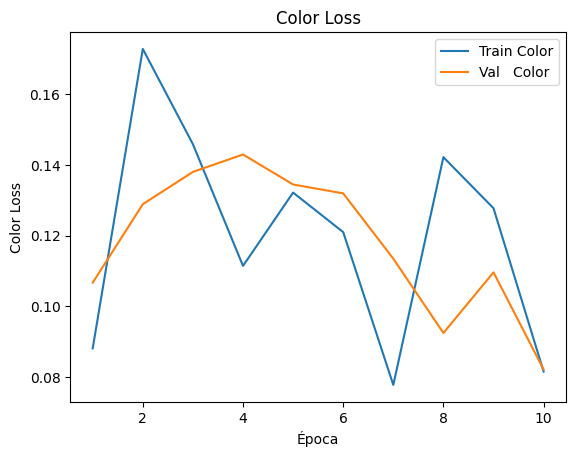

In [ ]:

from src.visualize import plot_losses
plot_losses(historial_perdidas, num_epochs=10)

#Las graficas actuales son muy  poco concluyentes porque modifiqué el dataset con solo 2 imagenes
#univamente para probar codigo, aunque mas abajo adjunté imagenes usando el dataset completo y con 40 epocas

<p>  
  Graficas de error usando 40 epocas:
</p>
<img src="./resources/PixelPerceptualLoss40.png"  width="1000"/>

<img src="./resources/AdversialLoss.png" width="500"/>

<img src="./resources/ColorLoss.png" width="500"/>



In [ ]:


'''Ejecutar esto solo si se quiere aplicar la super resolucion a partir de un checkpoint '''
ckpt = torch.load('./checkpointsConFormulaActualizada/checkpoint_epoch_5.pth', map_location=device)
generator.load_state_dict(ckpt['G_state_dict'])
generator.eval()

/tmp/ipykernel_13505/882965990.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load('./checkpointsConFormulaActualizada/checkpoint_epoch_40.pth', map_locati

RRDBNet(
  (conv_first): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (rrdb_trunk): Sequential(
    (0): RRDB(
      (rdb1): ResidualDenseBlock(
        (conv1): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(96, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv3): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv4): Conv2d(160, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv5): Conv2d(192, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (lrelu): LeakyReLU(negative_slope=0.2, inplace=True)
      )
      (rdb2): ResidualDenseBlock(
        (conv1): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(96, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv3): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv4): Conv2d(160, 32, kernel_size=(3, 3), stride=(1

In [21]:



def super_resolve_image(model,img_path,device,scale=4,tile_size=256,overlap=32):
    """
    Aplica la super resolucion a partir de un modelo ya entrenado

    Parametros:
        model: El modelo RRDBNet Entrenado.
        img_path: Direccion a la imagen que se le aplicará el escalado.
        device: Se ocupara para realizar el trabajo (cpu o gpu).
        scale: Factor de escalado, el modelo actual solo soporta 4 como input.
        tile_size: Tamaño de cada mosaico que se procesa de manera independiente.
        overlap: Longitud de cada mosaico para que se extienda sobre otro, sirve para evitar bordes visibles y tener una continuidad de texturas.

    """

    #Poner el modelo en modo evaluacion
    model.eval()
    lr_image = Image.open(img_path).convert("RGB")
    lr_np = np.array(lr_image).astype(np.float32) / 255.0  # Convertir en un array 
    h_lr, w_lr, _ = lr_np.shape #alto y largo
    h_hr, w_hr = h_lr * scale, w_lr * scale  # Dimensiones de salida

    output_sum = np.zeros((h_hr, w_hr, 3), dtype=np.float32)
    count_map = np.zeros((h_hr, w_hr, 3), dtype=np.float32)

    def process_tile(x0, y0, x1, y1):
        '''
        Recorta un mosaico de la imagen LR, lo procesa con el modelo y devuelve el
        mosaico HR resultante como arreglo NumPy en [0,1].

        Parametros:
            x0, y0: Coordenadas de la esquina superior izquierda del mosaico en LR.
            x1, y1: Coordenadas de la esquina inferior derecha del mosaico en LR.

        '''
        lr_tile = lr_np[y0:y1, x0:x1, :]
        # Convierte a tensor con forma [1, 3, H, W]
        lr_tensor = torch.from_numpy(lr_tile.transpose(2, 0, 1)).unsqueeze(0).to(device)
        with torch.no_grad():
            sr_tensor = model(lr_tensor)

        # Convierte el tensor de salida a NumPy en (H*scale, W*scale, 3)
        sr_np = sr_tensor.squeeze(0).clamp(0, 1).cpu().numpy().transpose(1, 2, 0)
        return sr_np

    stride = tile_size - overlap
    for y in range(0, h_lr, stride):
        for x in range(0, w_lr, stride):
            # Determina bordes del mosaico, sin exceder los límites de la image
            x_end = min(x + tile_size, w_lr)
            y_end = min(y + tile_size, h_lr)
            x0, y0 = x, y
            x1, y1 = x_end, y_end

         
            sr_tile = process_tile(x0, y0, x1, y1)
            # Calcular coordenadas en la version HR
            x0_hr, y0_hr = x0 * scale, y0 * scale
            x1_hr, y1_hr = x1 * scale, y1 * scale

            # Acumula valores de píxeles
            output_sum[y0_hr:y1_hr, x0_hr:x1_hr, :] += sr_tile
            count_map[y0_hr:y1_hr, x0_hr:x1_hr, :] += 1.0

    output_avg = output_sum / count_map
    output_img = (output_avg * 255.0).round().astype(np.uint8)     # Convierte de nuevo a uint8 en [0,255] (formato necesario para una imagen)
    return Image.fromarray(output_img)




In [26]:
#Uso final
#asegurarse que la imagen existe
lr_input_path = "./images/ciudad.jpg"
sr_output_path = "./scaledImages/ciudadX4_40Epocas.jpg"

sr_image = super_resolve_image(
    model=generator,
    img_path=lr_input_path,
    device=device,
    scale=4,
    tile_size=256,
    overlap=0
)

sr_image.save(sr_output_path)
print(f"Imagen escalada x4 guardada en: {sr_output_path}")

Imagen escalada x4 guardada en: ./scaledImages/ciudadX4_40Epocas.jpg


In [ ]:
#Referencias
#https://arxiv.org/pdf/1809.00219
#https://www.freecodecamp.org/news/an-intuitive-introduction-to-generative-adversarial-networks-gans-7a2264a81394
#https://pyimagesearch.com/2022/06/06/super-resolution-generative-adversarial-networks-srgan/